In [23]:
import sys, torch
print("python:", sys.executable)
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
try:
    print("arch_list:", torch.cuda.get_arch_list())
except Exception as e:
    print("arch_list error:", e)

python: C:\Users\morit\Documents\Python\Data-Science\.venv1\Scripts\python.exe
torch: 2.9.1+cu128
torch cuda: 12.8
is_available: True
arch_list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [24]:
import sys
!{sys.executable} -m pip show torch torchvision torchaudio

Name: torch
Version: 2.9.1+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: C:\Users\morit\Documents\Python\Data-Science\.venv1\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: captum, torchaudio, torchvision, ultralytics, ultralytics-thop
---
Name: torchvision
Version: 0.24.1+cu128
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: C:\Users\morit\Documents\Python\Data-Science\.venv1\Lib\site-packages
Requires: numpy, pillow, torch
Required-by: ultralytics
---
Name: torchaudio
Version: 2.9.1+cu128
Summary: An audio package for PyTorch
Home-page: https://github.com/pytorch/audio
Author: Soumith Chintala, David Pollack, 

In [25]:
# ============================================================
# NOTE (wichtig):
# - Wenn du PYTORCH_CUDA_ALLOC_CONF setzen willst (gegen Fragmentierung),
#   muss diese Zelle VOR dem ersten "import torch" laufen (Kernel frisch).
# ============================================================
import os

# Optional: hilft bei Fragmentierung in langen Notebook-Sessions
# (wirkt nur zuverlässig, wenn vor dem ersten torch-import gesetzt)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

'expandable_segments:True'

In [26]:
# 0) Setup: Imports, Seeds, Paths, Device + Watchdog
# ============================================================
from pathlib import Path
import random
import shutil
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# --- Reproduzierbarkeit ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Optional: Performance (meist sinnvoll bei CNNs)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# --- Device Logik: CUDA nur, wenn ein echter Kernel-Call klappt ---
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.randn(1, device="cuda")  # erzwingt echten Kernel-Launch
            return torch.device("cuda:0")
        except Exception as e:
            print("[WARN] CUDA erkannt, aber nicht nutzbar -> CPU-Fallback.")
            print("       Ursache:", str(e).splitlines()[0])
    return torch.device("cpu")

TORCH_DEVICE = pick_device()
CUDA_USABLE = (TORCH_DEVICE.type == "cuda")
YOLO_DEVICE = 0 if CUDA_USABLE else "cpu"  # Ultralytics: 0 = GPU0, sonst "cpu"

print("CUDA available (torch):", torch.cuda.is_available())
print("CUDA usable (kernel test):", CUDA_USABLE)
print("TORCH_DEVICE:", TORCH_DEVICE)
print("YOLO_DEVICE:", YOLO_DEVICE)
if CUDA_USABLE:
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

# --- Pfade ---
DATA_DIR = Path("..") / "Data"
LABELED_DIR = DATA_DIR / "SAP Bilder sortiert"
UNLABELED_DIR = DATA_DIR / "Ungelabelt"

WORK_DIR = Path("..") / "Work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# --- Hilfsfunktionen ---
def is_image(p: Path):
    return p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])

# ---------- GPU Watchdog ----------
MIN_FREE_MB_DEFAULT = 1500  # wenn weniger frei -> CPU-Fallback (anpassen nach Gefühl)

def _bytes_to_mb(x):
    return float(x) / (1024**2)

def cuda_mem_status():
    if not torch.cuda.is_available():
        return {"cuda": False}
    free_b, total_b = torch.cuda.mem_get_info()
    alloc_b = torch.cuda.memory_allocated()
    res_b = torch.cuda.memory_reserved()
    return {
        "cuda": True,
        "total_mb": _bytes_to_mb(total_b),
        "free_mb": _bytes_to_mb(free_b),
        "allocated_mb": _bytes_to_mb(alloc_b),
        "reserved_mb": _bytes_to_mb(res_b),
        "device": torch.cuda.get_device_name(0),
        "capability": torch.cuda.get_device_capability(0),
    }

def clear_jupyter_out_cache():
    # optional: kann helfen, wenn Out[] / _ große Objekte hält
    try:
        ip = get_ipython()  # noqa
        if "Out" in ip.user_ns:
            ip.user_ns["Out"].clear()
        for k in ["_", "__", "___"]:
            if k in ip.user_ns:
                ip.user_ns[k] = None
    except Exception:
        pass

def cuda_cleanup(clear_out_cache=False):
    if clear_out_cache:
        clear_jupyter_out_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
    gc.collect()

def ensure_best_device(min_free_mb=MIN_FREE_MB_DEFAULT, prefer_gpu=True, clear=True):
    """
    Wählt GPU wenn genug frei, sonst CPU. Macht optional Cleanup.
    Rückgabe: (device, use_cuda_bool)
    """
    if clear:
        cuda_cleanup(clear_out_cache=False)

    if prefer_gpu and torch.cuda.is_available():
        free_b, _total_b = torch.cuda.mem_get_info()
        free_mb = free_b / (1024**2)
        if free_mb >= float(min_free_mb):
            return torch.device("cuda:0"), True
    return torch.device("cpu"), False

def watchdog(min_free_mb=MIN_FREE_MB_DEFAULT, auto_set=True, clear=True, clear_out_cache=False, show=False):
    """
    Zeigt Status, macht Cleanup und setzt optional TORCH_DEVICE/CUDA_USABLE/YOLO_DEVICE passend.
    """
    before = cuda_mem_status()
    print("---- CUDA status (before) ----")
    print(before)

    if clear:
        cuda_cleanup(clear_out_cache=clear_out_cache)
    after = cuda_mem_status()
    print("---- CUDA status (after cleanup) ----")
    print(after)

    if auto_set:
        global TORCH_DEVICE, CUDA_USABLE, YOLO_DEVICE
        if after.get("cuda", False) and after["free_mb"] >= float(min_free_mb):
            TORCH_DEVICE = torch.device("cuda:0")
            CUDA_USABLE = True
            YOLO_DEVICE = 0
            print(f"[WATCHDOG] Using GPU (free {after['free_mb']:.0f} MB >= {min_free_mb} MB).")
        else:
            TORCH_DEVICE = torch.device("cpu")
            CUDA_USABLE = False
            YOLO_DEVICE = "cpu"
            if after.get("cuda", False):
                print(f"[WATCHDOG] GPU too full (free {after['free_mb']:.0f} MB < {min_free_mb} MB) -> CPU fallback.")
            else:
                print("[WATCHDOG] CUDA not available -> CPU fallback.")

    return after

CUDA available (torch): True
CUDA usable (kernel test): True
TORCH_DEVICE: cuda:0
YOLO_DEVICE: 0
GPU: NVIDIA GeForce RTX 5080
Capability: (12, 0)


,class,count
10,Excel,75
11,Query,72
4,Data Flow Object,44
9,DTP,42
8,Datenvorschau,41
12,Transformationen,39
2,BW4Cockpit (Stammdaten),38
0,ABAP Dictionary,33
6,Data Source,28
3,Composite Provider,17


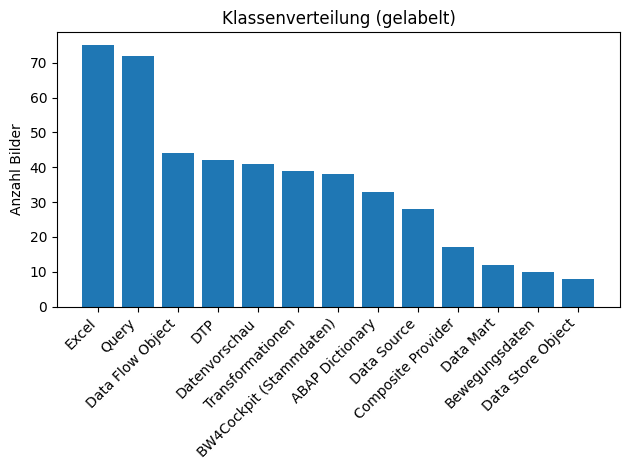

In [27]:
# 1) Klassenverteilung anzeigen (gelabelt)
# ============================================================
rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df)

plt.figure()
plt.bar(df["class"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt)")
plt.tight_layout()
plt.show()

In [28]:
# 2) Optional: Downsample-Plan berechnen (cap/target)
# ============================================================
counts = {}
for cls_dir in LABELED_DIR.iterdir():
    if cls_dir.is_dir():
        counts[cls_dir.name] = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))

s = pd.Series(counts).sort_values(ascending=False)
print("Counts:\n", s)

cap = 75
target = 50

downsample = (s - cap).clip(lower=0).astype(int)      # wie viele entfernen
topup      = (target - s).clip(lower=0).astype(int)   # wie viele ergänzen

print("\nDownsample (remove):\n", downsample[downsample > 0])
print("\nUnderrepresented vs target:\n", topup[topup > 0])
print("\nTotal missing to reach target:", int(topup.sum()))


Counts:
 Excel                      75
Query                      72
Data Flow Object           44
DTP                        42
Datenvorschau              41
Transformationen           39
BW4Cockpit (Stammdaten)    38
ABAP Dictionary            33
Data Source                28
Composite Provider         17
Data Mart                  12
Bewegungsdaten             10
Data Store Object           8
dtype: int64

Downsample (remove):
 Series([], dtype: int32)

Underrepresented vs target:
 Data Flow Object            6
DTP                         8
Datenvorschau               9
Transformationen           11
BW4Cockpit (Stammdaten)    12
ABAP Dictionary            17
Data Source                22
Composite Provider         33
Data Mart                  38
Bewegungsdaten             40
Data Store Object          42
dtype: int32

Total missing to reach target: 238


In [29]:
# 3) Optional: Downsample wirklich durchführen (Bilder wegbewegen)
# ============================================================
DO_DOWNSAMPLE = False  # <- auf True, wenn du wirklich Bilder verschieben willst

REDUCED_DIR = WORK_DIR / "reduced"
REDUCED_DIR.mkdir(parents=True, exist_ok=True)

rng = random.Random(seed)

def move_random_images(cls_name: str, n_remove: int):
    src_dir = LABELED_DIR / cls_name
    if not src_dir.exists():
        print(f"[WARN] Klasse nicht gefunden: {cls_name}")
        return 0

    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image(p)]
    if n_remove <= 0:
        return 0

    rng.shuffle(imgs)
    to_move = imgs[:min(n_remove, len(imgs))]

    dst_dir = REDUCED_DIR / cls_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    for p in to_move:
        shutil.move(str(p), str(dst_dir / p.name))

    return len(to_move)

if DO_DOWNSAMPLE:
    removed_total = 0
    for cls_name, n_remove in downsample.items():
        n_remove = int(n_remove)
        if n_remove > 0:
            moved = move_random_images(cls_name, n_remove)
            removed_total += moved
            print(f"Reduced {cls_name}: moved {moved} images -> {REDUCED_DIR / cls_name}")
    print("Total moved:", removed_total)
else:
    print("DO_DOWNSAMPLE=False -> nichts verschoben.")

DO_DOWNSAMPLE=False -> nichts verschoben.


In [30]:
# 4) Optional: Unlabeled Holdout/Candidate Split (CSV)
# ============================================================
DO_UNLABELED_SPLIT = False  # <- falls ihr das wirklich nutzen wollt

SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

if DO_UNLABELED_SPLIT:
    unlabeled_all = list_images(UNLABELED_DIR)
    print("Unlabeled total:", len(unlabeled_all))

    holdout_ratio = 0.50
    idx = list(range(len(unlabeled_all)))
    rng.shuffle(idx)

    holdout_n = int(len(unlabeled_all) * holdout_ratio)
    holdout_idx = set(idx[:holdout_n])

    unlabeled_holdout   = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i in holdout_idx]
    unlabeled_candidate = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i not in holdout_idx]

    print("Holdout:", len(unlabeled_holdout))
    print("Candidate:", len(unlabeled_candidate))

    pd.DataFrame({"path": [str(p) for p in unlabeled_holdout]}).to_csv(SPLITS_DIR / "unlabeled_holdout.csv", index=False)
    pd.DataFrame({"path": [str(p) for p in unlabeled_candidate]}).to_csv(SPLITS_DIR / "unlabeled_candidate.csv", index=False)
else:
    print("DO_UNLABELED_SPLIT=False -> keine CSVs erzeugt.")

DO_UNLABELED_SPLIT=False -> keine CSVs erzeugt.


In [31]:
# 5) Train/Val Split als Ordnerstruktur (ImageFolder kompatibel)
# ============================================================
SPLIT_DIR = WORK_DIR / "datasets" / "base_split"
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

val_ratio = 0.2

def safe_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)

for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    cls = cls_dir.name
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and is_image(p)]
    rng.shuffle(imgs)
    if len(imgs) == 0:
        continue

    n_val = max(1, int(len(imgs) * val_ratio))
    val_imgs = imgs[:n_val]
    train_imgs = imgs[n_val:]

    for p in train_imgs:
        safe_copy(p, TRAIN_DIR / cls / p.name)
    for p in val_imgs:
        safe_copy(p, VAL_DIR / cls / p.name)

print("Split erstellt:", SPLIT_DIR)

Split erstellt: ..\Work\datasets\base_split


In [32]:
# 6) YOLO Training (GPU wenn möglich; sonst CPU)
# ============================================================
from ultralytics import YOLO

# Vor YOLO: optional Watchdog, um GPU zu nutzen wenn frei
watchdog(min_free_mb=2000, auto_set=True, clear=True)

# Finetune (pretrained) – das gibt normalerweise den Epoch-Progress aus
yolo_model = YOLO("yolov8n-cls.pt")
yolo_model.train(
    data=str(SPLIT_DIR),
    imgsz=224,
    epochs=100,
    batch=32,      # falls OOM: 16 oder 8
    workers=2,     # falls Windows/Probleme: 0
    device=YOLO_DEVICE,
    verbose=True
)

# Optional: Validierung direkt danach (kann bei dir manchmal Probleme machen -> dann überspringen)
DO_YOLO_VAL_AFTER_TRAIN = True
if DO_YOLO_VAL_AFTER_TRAIN:
    try:
        m2 = yolo_model.val(data=str(SPLIT_DIR), device=YOLO_DEVICE)
        print("YOLO finetuned:", m2)
    except Exception as e:
        print("[WARN] yolo_model.val() übersprungen/fehlgeschlagen:", str(e).splitlines()[0])

# Nach YOLO: Cache leeren (hilft, bevor ResNet kommt)
cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14207.0, 'allocated_mb': 450.74072265625, 'reserved_mb': 660.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14207.0, 'allocated_mb': 450.74072265625, 'reserved_mb': 660.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14207 MB >= 2000 MB).
Ultralytics 8.3.252  Python-3.12.10 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Work\datasets\base_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_o

In [33]:
# 7) ResNet Setup (DataLoaders, Transforms, auto GPU/CPU)
# ============================================================
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# Empfehlung: auf Windows num_workers=0 ist stabiler
NUM_WORKERS = 0
BATCH_TRAIN = 32  # falls OOM: 16
BATCH_VAL   = 32  # falls OOM: 16

weights = models.ResNet18_Weights.IMAGENET1K_V1
val_tf = weights.transforms()
mean = weights.transforms().mean
std  = weights.transforms().std

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(str(VAL_DIR), transform=val_tf)

class_names = train_ds.classes
n_classes = len(class_names)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)

print("Klassen (ImageFolder-Reihenfolge):", class_names)
print("n_classes:", n_classes)


Klassen (ImageFolder-Reihenfolge): ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
n_classes: 13


In [34]:
# 8) ResNet Eval (auto GPU->CPU) + Baselines
# ============================================================
def eval_model_auto(model, loader, min_free_mb=1200):
    device, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model = model.to(device).eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device, non_blocking=use_cuda)
            logits = model(x)
            pred = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc, device

# Baseline A: random
resnet_untrained = models.resnet18(weights=None)
resnet_untrained.fc = nn.Linear(resnet_untrained.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_untrained, val_loader)
print("RESNET untrained baseline acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Baseline B: pretrained backbone, neuer Kopf (untrainiert)
resnet_pre = models.resnet18(weights=weights)
resnet_pre.fc = nn.Linear(resnet_pre.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_pre, val_loader)
print("RESNET pretrained (no finetune) acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

RESNET untrained baseline acc: 0.046511627906976744 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.00      0.00      0.00         6
BW4Cockpit (Stammdaten)       0.00      0.00      0.00         7
         Bewegungsdaten       0.00      0.00      0.00         2
     Composite Provider       0.04      1.00      0.07         3
                    DTP       0.00      0.00      0.00         8
       Data Flow Object       0.00      0.00      0.00         8
              Data Mart       0.00      0.00      0.00         2
            Data Source       0.00      0.00      0.00         5
      Data Store Object       0.00      0.00      0.00         1
          Datenvorschau       0.11      0.12      0.12         8
                  Excel       0.00      0.00      0.00        15
                  Query       0.00      0.00      0.00        14
       Transformationen       0.00      0.00      0.00         7

               accu

In [35]:
# 9) ResNet Fine-Tuning (AMP wenn CUDA; ansonsten CPU)
# ============================================================
CKPT = WORK_DIR / "resnet18_best.pt"
HIST = WORK_DIR / "resnet18_history.csv"

# Vor Training: nutze GPU wenn ausreichend frei
watchdog(min_free_mb=2500, auto_set=True, clear=True)

device = TORCH_DEVICE
use_amp = (device.type == "cuda")

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=use_amp)


def train_one_epoch(model):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=CUDA_USABLE)
        y = y.to(device, non_blocking=CUDA_USABLE)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(train_loader.dataset)


best_acc = 0.0
history = []
epochs = 100

for epoch in range(1, epochs + 1):
    loss = train_one_epoch(model)

    # Val: auto GPU->CPU falls nötig
    y_true, y_pred, val_acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
    print(f"Epoch {epoch:02d} | loss={loss:.4f} | val_acc={val_acc:.4f} | val_device={dev}")

    history.append({"epoch": epoch, "train_loss": loss, "val_acc": val_acc})
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CKPT)

pd.DataFrame(history).to_csv(HIST, index=False)
print("Best val_acc:", best_acc)
print("Saved:", CKPT)
print("Saved:", HIST)

cuda_cleanup()


---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 13879.0, 'allocated_mb': 453.47705078125, 'reserved_mb': 988.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14075.0, 'allocated_mb': 453.47705078125, 'reserved_mb': 792.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14075 MB >= 2500 MB).


C:\Users\morit\AppData\Local\Temp\ipykernel_29544\1475042860.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
C:\Users\morit\AppData\Local\Temp\ipykernel_29544\1475042860.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | loss=1.3726 | val_acc=0.6163 | val_device=cuda:0
Epoch 02 | loss=0.2941 | val_acc=0.8605 | val_device=cuda:0
Epoch 03 | loss=0.1002 | val_acc=0.9186 | val_device=cuda:0
Epoch 04 | loss=0.0680 | val_acc=0.9302 | val_device=cuda:0
Epoch 05 | loss=0.0503 | val_acc=0.9186 | val_device=cuda:0
Epoch 06 | loss=0.0321 | val_acc=0.9302 | val_device=cuda:0
Epoch 07 | loss=0.0208 | val_acc=0.9186 | val_device=cuda:0
Epoch 08 | loss=0.0129 | val_acc=0.9186 | val_device=cuda:0
Epoch 09 | loss=0.0089 | val_acc=0.9302 | val_device=cuda:0
Epoch 10 | loss=0.0146 | val_acc=0.9302 | val_device=cuda:0
Epoch 11 | loss=0.0059 | val_acc=0.9302 | val_device=cuda:0
Epoch 12 | loss=0.0089 | val_acc=0.9186 | val_device=cuda:0
Epoch 13 | loss=0.0051 | val_acc=0.9070 | val_device=cuda:0
Epoch 14 | loss=0.0116 | val_acc=0.9186 | val_device=cuda:0
Epoch 15 | loss=0.0040 | val_acc=0.9302 | val_device=cuda:0
Epoch 16 | loss=0.0079 | val_acc=0.9186 | val_device=cuda:0
Epoch 17 | loss=0.0165 | val_acc=0.8953 

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14033 MB >= 1500 MB).
RESNET finetuned acc: 0.9418604651162791 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       1.00      1.00      1.00         6
BW4Cockpit (Stammdaten)       1.00      0.86      0.92         7
         Bewegungsdaten       0.67      1.00      0.80         2
     Composite Provider       1.00      1.00      1.00         3
                    DTP       1.00      0.88      0.93         8
       Data Flow Object       1.00      1.00      1.00         8
              Data M

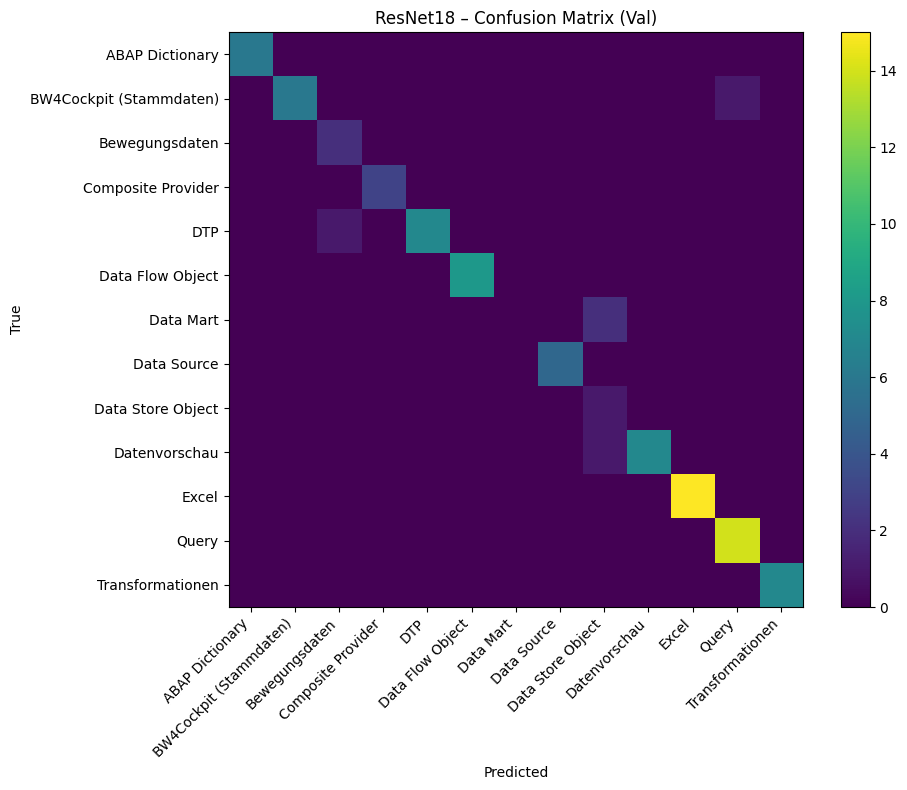

In [45]:
# 10) Bestes ResNet laden + Report + Confusion Matrix (auto GPU->CPU)
# ============================================================
# Für XAI/Report ist es oft besser, wenn GPU frei ist; wir nehmen auto.
watchdog(min_free_mb=1500, auto_set=True, clear=True)

device = TORCH_DEVICE

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.to(device).eval()

y_true, y_pred, acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
print("RESNET finetuned acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("ResNet18 – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 412.2626953125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 412.2626953125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14033 MB >= 1500 MB).
YOLO finetuned classification_report:
                         precision    recall  f1-score   support

        ABAP Dictionary       1.00      1.00      1.00         6
BW4Cockpit (Stammdaten)       1.00      0.86      0.92         7
         Bewegungsdaten       1.00      1.00      1.00         2
     Composite Provider       1.00      1.00      1.00         3
                    DTP       1.00      0.88      0.93         8
       Data Flow Object       1.00      1.00      1.00         8
              Data Mart       1.00      1.

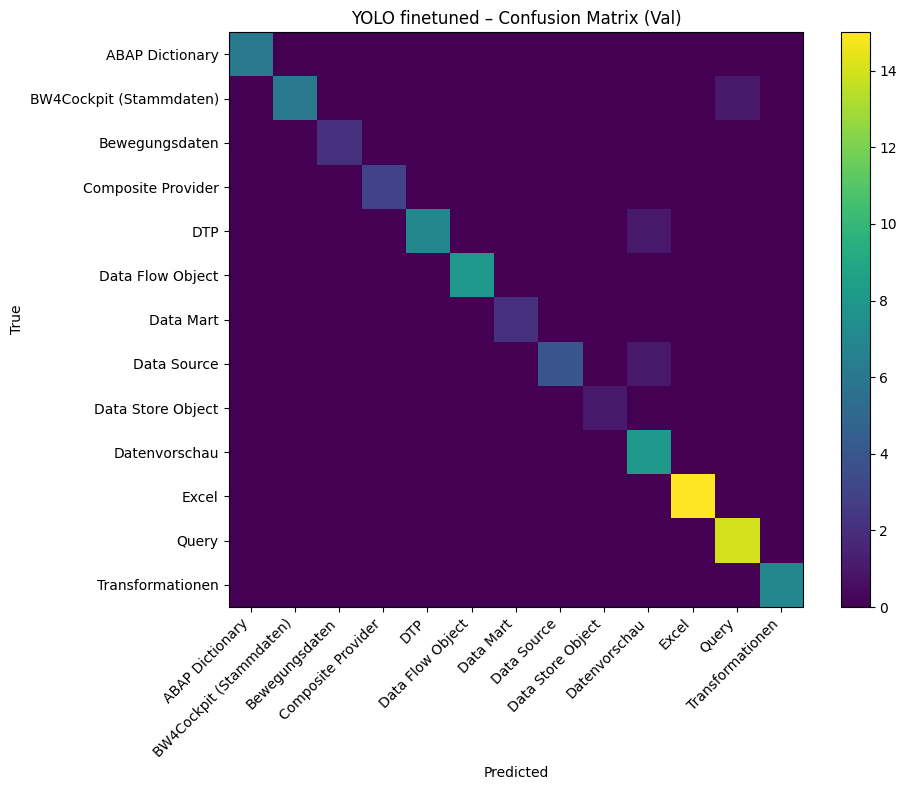

In [37]:
# 11) YOLO finetuned – Report + Confusion Matrix (wie ResNet #10; stabil ohne Ultralytics predict/val)
# ============================================================
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# Tipp: falls GPU voll: watchdog() wird automatisch CPU setzen
watchdog(min_free_mb=1500, auto_set=True, clear=True)

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean_, std=std_),
        ])

def yolo_logits(yolo_obj, x):
    m = yolo_obj.model
    core = getattr(m, "model", None)
    out = core(x) if core is not None else m(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def get_idx_to_name(yolo_obj):
    names = getattr(yolo_obj, "names", None)
    if names is None and hasattr(yolo_obj, "model"):
        names = getattr(yolo_obj.model, "names", None)
    if isinstance(names, dict):
        return {int(k): v for k, v in names.items()}
    if isinstance(names, (list, tuple)):
        return {i: n for i, n in enumerate(names)}
    return None

# Device für YOLO-Auswertung (GPU wenn frei, sonst CPU)
yolo_eval_device = TORCH_DEVICE
yolo_use_amp = (yolo_eval_device.type == "cuda")

tf_yolo = get_yolo_cls_transform(224)
idx_to_name = get_idx_to_name(yolo_model)
class_to_idx = {c: i for i, c in enumerate(class_names)}

yolo_model.model.to(yolo_eval_device).eval()

val_paths = [Path(p) for p, _ in val_ds.samples]
y_true = np.array([y for _, y in val_ds.samples], dtype=int)

BATCH = 16  # falls OOM: 8
y_pred = np.empty(len(val_paths), dtype=int)

with torch.inference_mode():
    for start in range(0, len(val_paths), BATCH):
        chunk = val_paths[start:start + BATCH]
        imgs = [tf_yolo(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0).to(yolo_eval_device, non_blocking=yolo_use_amp)

        if yolo_use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = yolo_logits(yolo_model, x)
        else:
            logits = yolo_logits(yolo_model, x)

        top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

        for i, pred_idx in enumerate(top1):
            if idx_to_name is not None:
                pred_name = idx_to_name.get(int(pred_idx), None)
                if pred_name in class_to_idx:
                    y_pred[start + i] = class_to_idx[pred_name]
                else:
                    y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0
            else:
                y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0

print("YOLO finetuned classification_report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm_yolo = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm_yolo)
plt.title("YOLO finetuned – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

In [38]:
# 12) XAI Dependencies (Captum) + Helpers
# ============================================================
import sys
from PIL import ImageFilter

# Captum installieren falls nötig
try:
    import captum
    print("captum version:", captum.__version__)
except Exception:
    # In PyCharm/Jupyter funktioniert "!" normalerweise
    !{sys.executable} -m pip install -U captum
    import captum
    print("captum version:", captum.__version__)

from captum.attr import IntegratedGradients, NoiseTunnel

def show_overlay(img_pil, heatmap_2d, title, alpha=0.45, q=0.99):
    hm = np.array(heatmap_2d, dtype=np.float32)
    hm = hm - hm.min()
    vmax = np.quantile(hm, q) if hm.size else 1.0
    if vmax > 0:
        hm = np.clip(hm / vmax, 0, 1)

    img = np.array(img_pil.convert("RGB").resize((hm.shape[1], hm.shape[0])))

    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.imshow(hm, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def attr_to_heatmap(attr_tensor):
    a = attr_tensor.squeeze(0).detach().cpu().numpy()  # (3,H,W)
    hm = np.sum(np.abs(a), axis=0)                     # (H,W)
    return hm

def pick_val_image(k=0):
    p, y = val_ds.samples[k]
    return Path(p), int(y)

captum version: 0.8.0


File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png


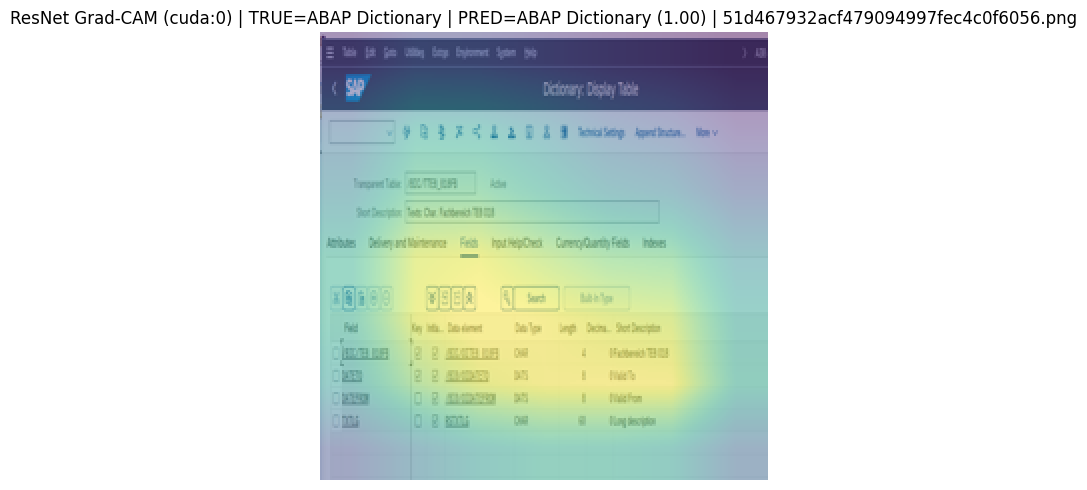

In [39]:
# 13) ResNet XAI: Grad-CAM (auto GPU->CPU)
# ============================================================
import torch.nn.functional as F

def gradcam_resnet(model, input_tensor, target_layer):
    model.eval()

    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    try:
        h2 = target_layer.register_full_backward_hook(bwd_hook)
    except Exception:
        h2 = target_layer.register_backward_hook(bwd_hook)

    input_tensor = input_tensor.requires_grad_(True)
    logits = model(input_tensor)

    pred_idx = int(logits.argmax(dim=1).item())
    probs = torch.softmax(logits.detach(), dim=1)[0]
    pred_conf = float(probs[pred_idx].item())

    model.zero_grad(set_to_none=True)
    score = logits[0, pred_idx]
    score.backward()

    h1.remove()
    h2.remove()

    act = activations[0]  # (1,C,h,w)
    grad = gradients[0]   # (1,C,h,w)

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)

    cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()

    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, pred_idx, pred_conf

def gradcam_auto(img_path, min_free_mb=1200):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = val_tf(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)

    cam, pred_idx, pred_conf = gradcam_resnet(model, x, target_layer=model.layer4[-1])
    return img_pil, cam, pred_idx, pred_conf, dev

# Beispiel
img_path, true_idx = pick_val_image(0)
img_pil, cam, pred_idx, pred_conf, dev = gradcam_auto(img_path, min_free_mb=1200)
title = f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({pred_conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png


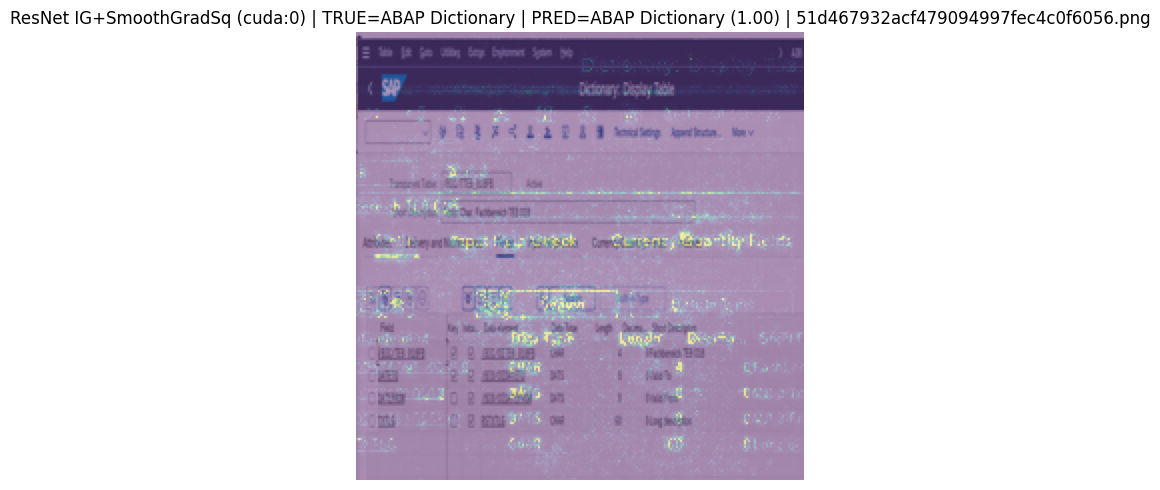

In [41]:
# 14) ResNet XAI: Integrated Gradients + SmoothGradSq (auto GPU->CPU)
# ============================================================
def ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,
    n_steps_cpu=48, nt_samples_cpu=12,
    stdevs=0.15,
    use_blur_baseline=True
):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    model.to(dev).eval()
    img_pil = Image.open(img_path).convert("RGB")

    x = val_tf(img_pil).unsqueeze(0).to(dev)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = val_tf(blur).unsqueeze(0).to(dev)

    def forward_fn(t):
        return model(t)

    with torch.enable_grad():
        logits = forward_fn(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(forward_fn)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x, baselines=baselines, target=pred_idx,
            n_steps=n_steps, nt_type="smoothgrad_sq",
            nt_samples=nt_samples, stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, dev

# Beispiel
img_path, true_idx = pick_val_image(0)
img_pil, attr, pred_idx, conf, dev = ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8
)
hm = attr_to_heatmap(attr)
title = f"ResNet IG+SmoothGradSq ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

Val acc (CPU eval): 0.9418604651162791
Misclassified: 5
File: ..\Work\datasets\base_split\val\BW4Cockpit (Stammdaten)\063f559b77c6468d9f0e78d3d1a0d595.png


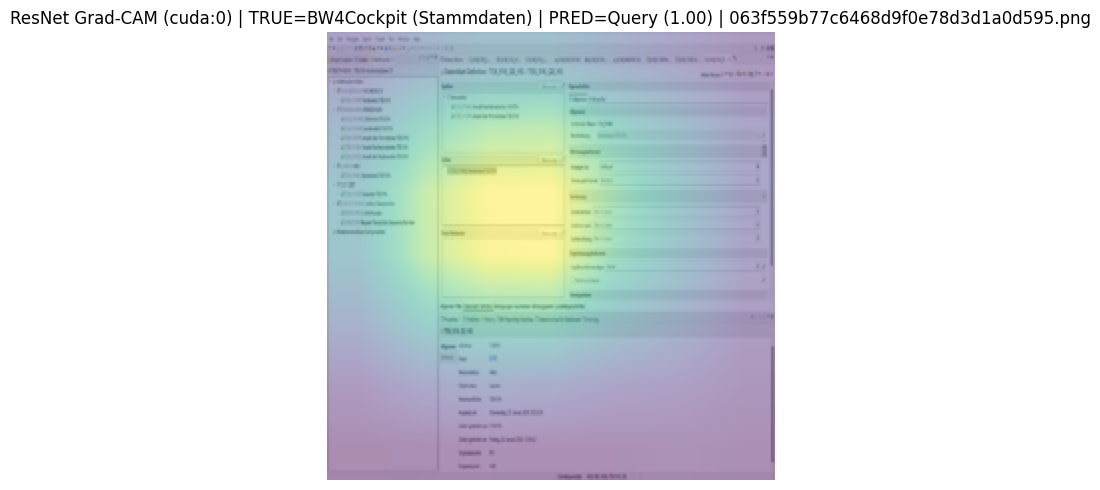

File: ..\Work\datasets\base_split\val\DTP\image_page24_2.png


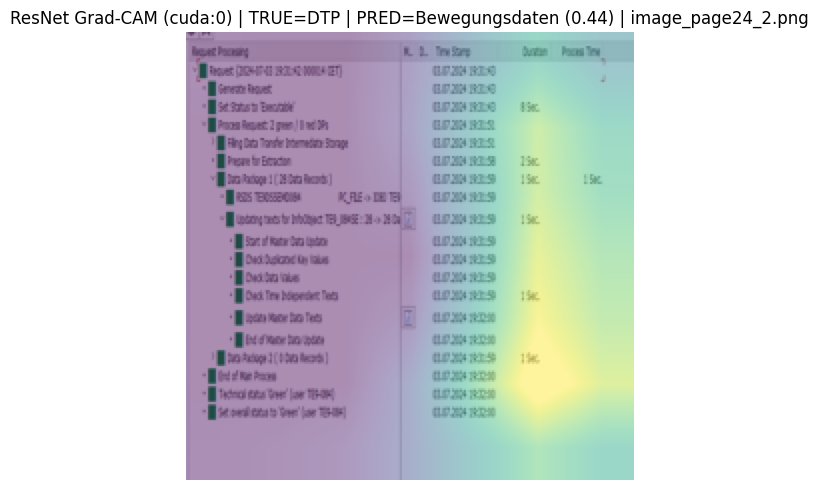

File: ..\Work\datasets\base_split\val\Data Mart\410b5353c3fd41d0a039a4fe10e9c43b.png


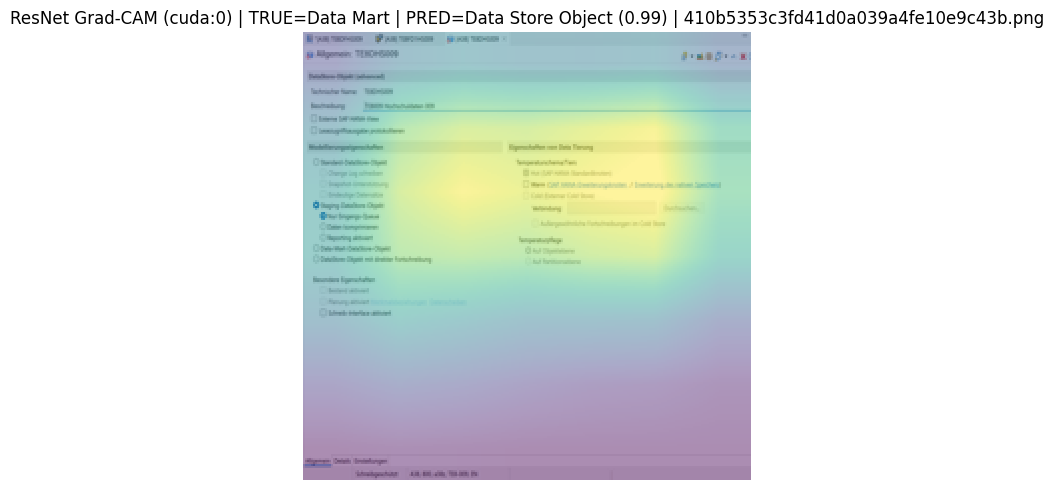

File: ..\Work\datasets\base_split\val\Data Mart\7e9ac1a5eb3d475e810a8e4ba1305f02.png


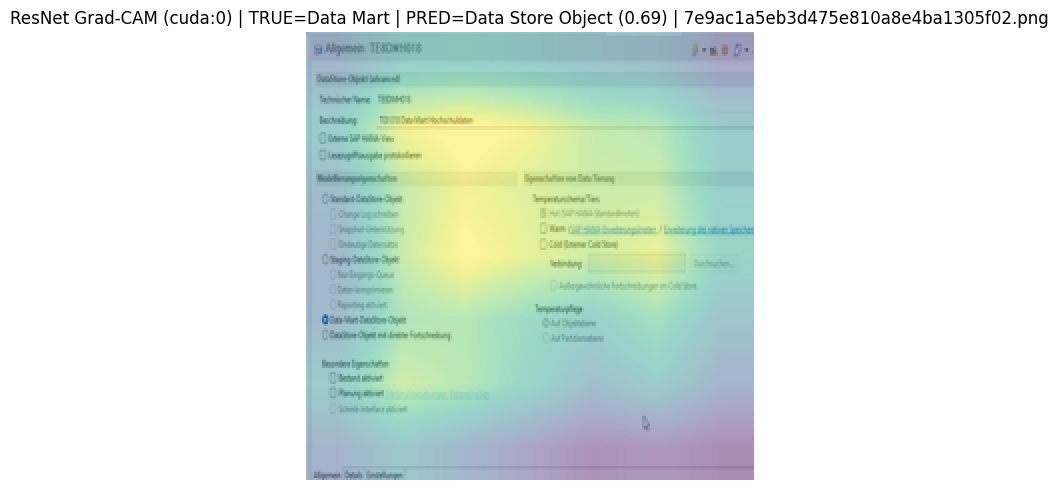

File: ..\Work\datasets\base_split\val\Datenvorschau\image_page3_2.png


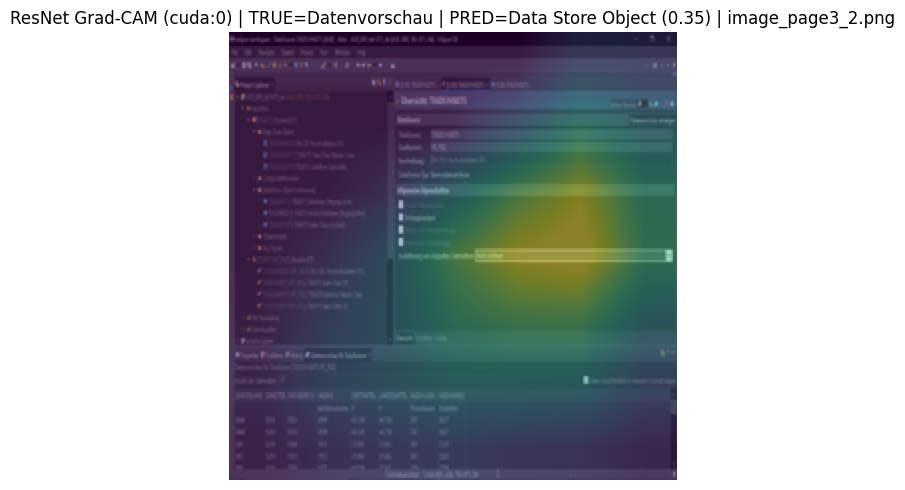

In [42]:
# 15) ResNet: Fehlklassifikationen finden + XAI (Grad-CAM) anzeigen (OOM-sicher)
# ============================================================
# Idee: y_true/y_pred stabil berechnen (notfalls CPU), danach Grad-CAM pro Bild auto GPU->CPU.

# Stabiler Val-Loader für CPU (keine pin_memory, keine workers)
val_loader_cpu = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

def eval_model_cpu(model, loader):
    model_cpu = model.to("cpu").eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            logits = model_cpu(x)
            pred = logits.argmax(dim=1).numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc

# 1) Erstmal CPU-eval, damit es nie crasht:
y_true, y_pred, acc = eval_model_cpu(model, val_loader_cpu)
print("Val acc (CPU eval):", acc)

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified:", len(mis_idx))

# 2) Zeige N Fehlklassifikationen mit Grad-CAM (auto GPU->CPU)
N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true[k])
    pred_idx_expected = int(y_pred[k])

    img_pil, cam, pred_idx_cam, pconf, dev = gradcam_auto(img_path, min_free_mb=1200)
    title = (
        f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | "
        f"PRED={class_names[pred_idx_expected]} ({pconf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14033 MB >= 2500 MB).
Using YOLO best.pt: runs\classify\train12\weights\best.pt
File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png


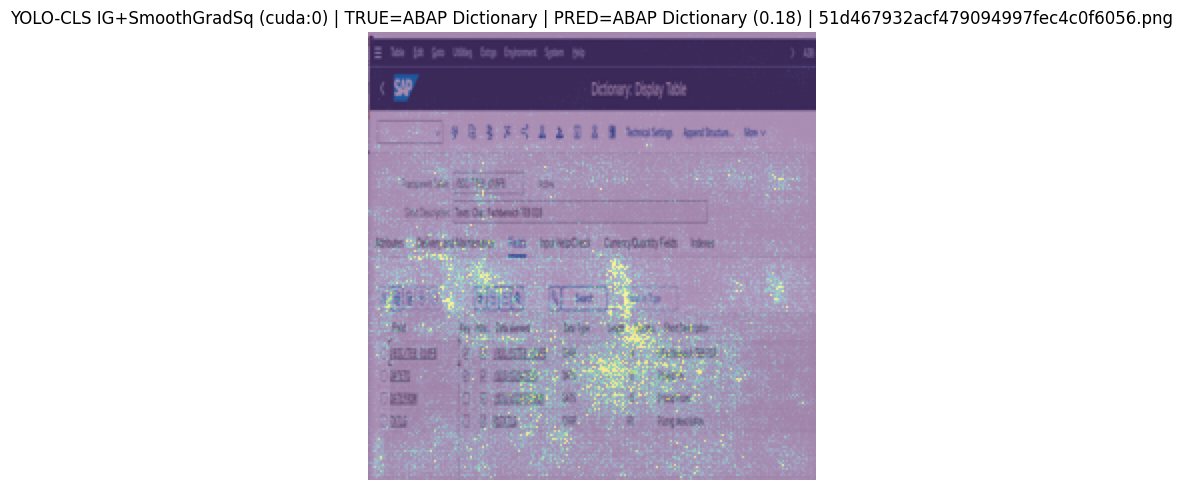

In [43]:
# 16) YOLO-CLS XAI: best.pt laden + Integrated Gradients (SmoothGradSq) (auto GPU->CPU, OOM-sicher)
# ============================================================
from pathlib import Path
import gc
import torch
import numpy as np
from PIL import Image, ImageFilter
from ultralytics import YOLO
from captum.attr import IntegratedGradients, NoiseTunnel

# Empfehlung: vor XAI einmal Watchdog (IG braucht eher mehr freie VRAM)
watchdog(min_free_mb=2500, auto_set=True, clear=True)

# --- best.pt suchen (neuester Run) ---
RUNS = Path("runs") / "classify"
if not RUNS.exists():
    alt = Path("src") / "runs" / "classify"
    if alt.exists():
        RUNS = alt

best_pts = sorted(RUNS.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not best_pts:
    raise FileNotFoundError(f"Kein best.pt gefunden unter: {RUNS}")

BEST_PT = best_pts[0]
print("Using YOLO best.pt:", BEST_PT)

# --- Modell laden ---
yolo_xai = YOLO(str(BEST_PT))

# Modell extrahieren (robust): yolo_xai.model.model ist meist Sequential bei classify
base_model = getattr(yolo_xai, "model", None)
seq = getattr(base_model, "model", None) if base_model is not None else None
if seq is None:
    if base_model is None:
        raise RuntimeError("Konnte YOLO Modell nicht extrahieren (yolo_xai.model fehlt).")
    seq = base_model  # fallback

# idx -> class name mapping
names = getattr(yolo_xai, "names", None)
if isinstance(names, dict):
    idx_to_name = {int(k): v for k, v in names.items()}
elif isinstance(names, (list, tuple)):
    idx_to_name = {i: n for i, n in enumerate(names)}
else:
    idx_to_name = {}

# --- Transform: PIL -> Tensor (3,224,224) ---
def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

tf_yolo = get_yolo_cls_transform(224)

def yolo_forward(x):
    out = seq(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,     # GPU: kleiner
    n_steps_cpu=48, nt_samples_cpu=12,    # CPU: größer ok
    stdevs=0.15,
    use_blur_baseline=True
):
    """
    Läuft bevorzugt auf GPU (wenn genug frei), sonst CPU.
    Returns: img_pil, attr, pred_idx, conf, probs, device_used
    """
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    # Modell auf Device
    seq.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = tf_yolo(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = tf_yolo(blur).unsqueeze(0).to(dev, non_blocking=use_cuda)

    with torch.enable_grad():
        logits = yolo_forward(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(yolo_forward)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x,
            baselines=baselines,
            target=pred_idx,
            n_steps=n_steps,
            nt_type="smoothgrad_sq",
            nt_samples=nt_samples,
            stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, probs, dev

# --- Beispiel auf einem Val-Bild ---
img_path = Path(val_ds.samples[0][0])
true_idx = int(val_ds.samples[0][1])

img_pil, attr, pred_idx, conf, probs, dev_used = ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8,
    stdevs=0.15,
    use_blur_baseline=True
)

hm = attr_to_heatmap(attr)
pred_name = idx_to_name.get(pred_idx, str(pred_idx))
title = f"YOLO-CLS IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | PRED={pred_name} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14033.0, 'allocated_mb': 456.37939453125, 'reserved_mb': 834.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14033 MB >= 1500 MB).
YOLO val acc (manual): 0.9651162790697675 | pred_device: cuda:0
YOLO Misclassified: 3
File: ..\Work\datasets\base_split\val\BW4Cockpit (Stammdaten)\063f559b77c6468d9f0e78d3d1a0d595.png


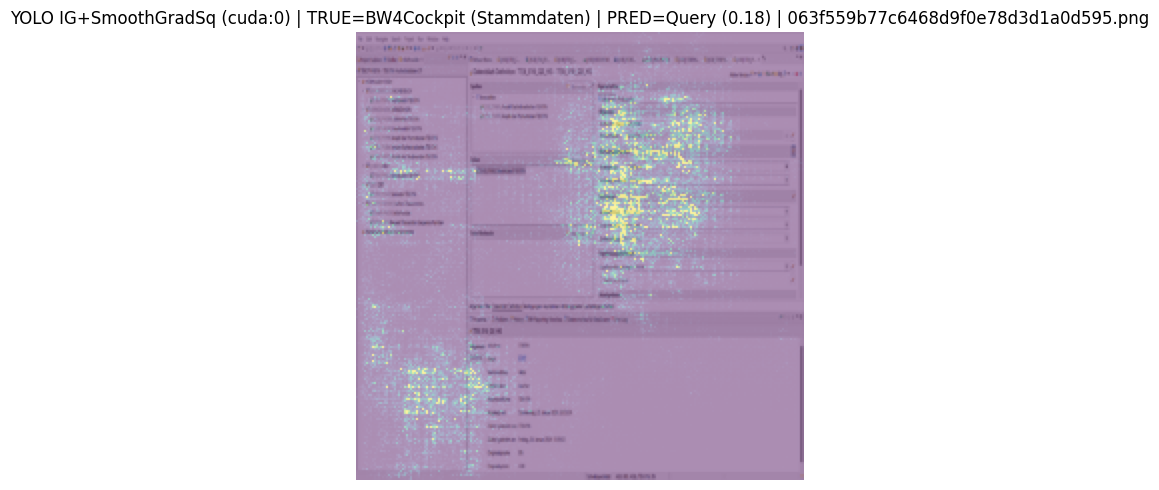

File: ..\Work\datasets\base_split\val\DTP\image_page24_2.png


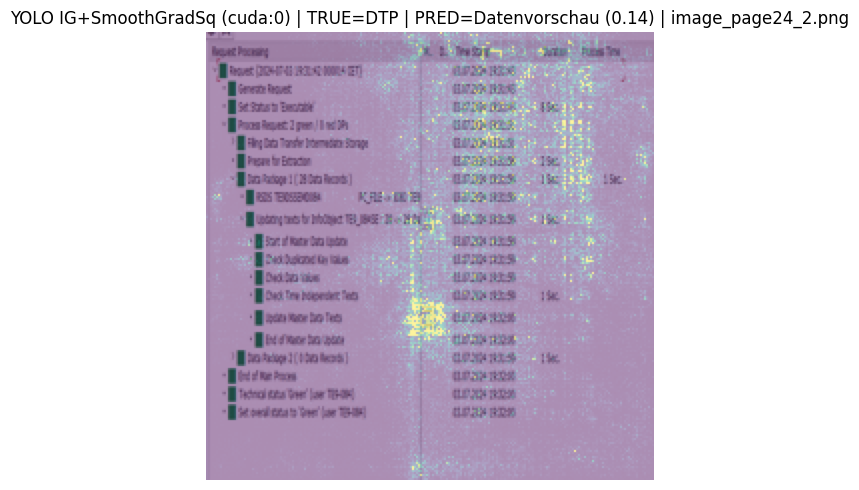

File: ..\Work\datasets\base_split\val\Data Source\ea00bd5f5c9b4ccba4260c1899a2f2d1.jpeg


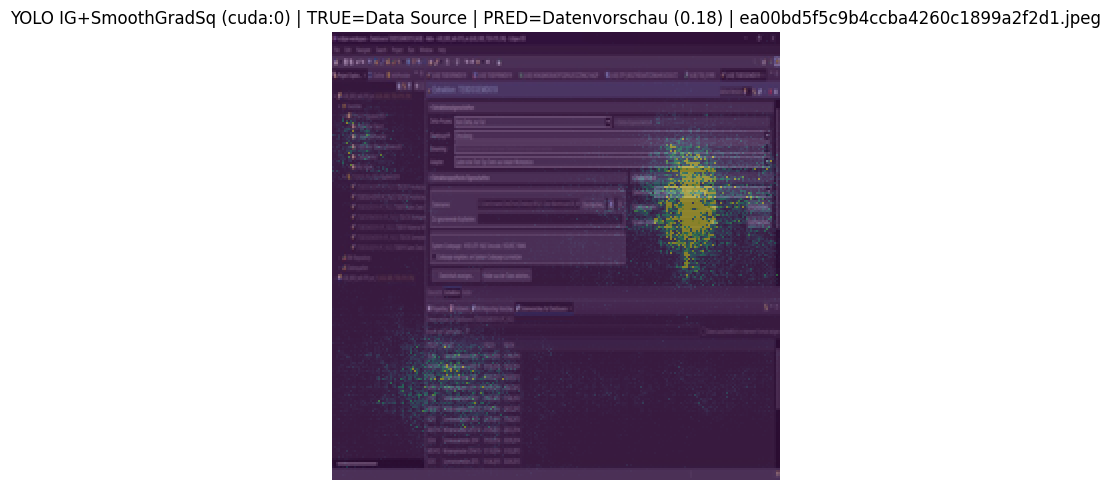

In [44]:
# 17) YOLO: Fehlklassifikationen finden + XAI (IG+SmoothGradSq) anzeigen (OOM-sicher, wie ResNet #15)
# ============================================================
import numpy as np
from pathlib import Path
from PIL import Image

# Wichtig: wir erstellen y_true/y_pred stabil OHNE ultralytics.predict/val,
# weil du dort Transforms/OOM-Probleme hattest.

# 1) YOLO Vorhersagen für das ganze Val-Set (kleiner Batch)
def yolo_predict_labels_manual(yolo_obj, val_ds, class_names, imgsz=224, batch=16, min_free_mb=1500):
    """
    Gibt y_true (aus val_ds.samples) und y_pred (gemappt auf ImageFolder class idx) zurück.
    Läuft auto GPU->CPU.
    """
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    # Modell/seq sicherstellen
    base = getattr(yolo_obj, "model", None)
    seq_local = getattr(base, "model", None) if base is not None else None
    if seq_local is None:
        seq_local = base
    if seq_local is None:
        raise RuntimeError("Konnte YOLO seq nicht extrahieren.")

    seq_local.to(dev).eval()

    # idx->name mapping
    names_local = getattr(yolo_obj, "names", None)
    if isinstance(names_local, dict):
        idx_to_name_local = {int(k): v for k, v in names_local.items()}
    elif isinstance(names_local, (list, tuple)):
        idx_to_name_local = {i: n for i, n in enumerate(names_local)}
    else:
        idx_to_name_local = {}

    tf_local = get_yolo_cls_transform(imgsz)
    class_to_idx_local = {c: i for i, c in enumerate(class_names)}

    val_paths = [Path(p) for p, _ in val_ds.samples]
    y_true = np.array([y for _, y in val_ds.samples], dtype=int)
    y_pred = np.empty(len(val_paths), dtype=int)

    def forward_local(x):
        out = seq_local(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        return out

    with torch.inference_mode():
        for start in range(0, len(val_paths), batch):
            chunk = val_paths[start:start+batch]
            imgs = [tf_local(Image.open(p).convert("RGB")) for p in chunk]
            x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_cuda)

            # AMP nur wenn CUDA
            if dev.type == "cuda":
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    logits = forward_local(x)
            else:
                logits = forward_local(x)

            top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

            for i, pred_idx in enumerate(top1):
                # 1) bevorzugt mapping über class name
                pred_name = idx_to_name_local.get(int(pred_idx), None)

                if pred_name in class_to_idx_local:
                    y_pred[start+i] = class_to_idx_local[pred_name]
                else:
                    # 2) fallback: wenn pred_idx schon im gültigen Bereich ist
                    if 0 <= int(pred_idx) < len(class_names):
                        y_pred[start+i] = int(pred_idx)
                    else:
                        # 3) harter fallback
                        y_pred[start+i] = 0

    return y_true, y_pred, dev

# 2) Fehlklassifikationen finden
watchdog(min_free_mb=1500, auto_set=True, clear=True)

y_true_yolo, y_pred_yolo, dev_pred = yolo_predict_labels_manual(
    yolo_xai, val_ds, class_names,
    imgsz=224,
    batch=16,          # falls OOM: 8
    min_free_mb=1500
)

acc_yolo = float((y_true_yolo == y_pred_yolo).mean())
print("YOLO val acc (manual):", acc_yolo, "| pred_device:", dev_pred)

mis_idx = np.where(y_true_yolo != y_pred_yolo)[0]
print("YOLO Misclassified:", len(mis_idx))

# 3) XAI für N Fehlklassifikationen (IG+SmoothGradSq, auto GPU->CPU)
N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true_yolo[k])
    pred_idx = int(y_pred_yolo[k])

    img_pil, attr, pred_idx_logits, conf, probs, dev_used = ig_yolo_smooth_auto(
        img_path,
        min_free_mb=2500,      # IG braucht meist mehr
        n_steps_gpu=24,
        nt_samples_gpu=8,
        stdevs=0.15,
        use_blur_baseline=True
    )

    hm = attr_to_heatmap(attr)
    pred_name = class_names[pred_idx]  # gemappt auf ImageFolder-Index

    title = (
        f"YOLO IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | "
        f"PRED={pred_name} ({conf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()